## Estimation


**Estimation** is a statistical method used to infer population parameters based on sample data. It is categorized into:

1. **Point Estimation**: Provides a single best estimate for a population parameter (e.g., sample mean $\bar{x}$ for population mean $\mu$ but doesn't indicate reliability.

2. **Confidence Interval Estimation**: Offers a range of values likely to contain the population parameter, accompanied by a confidence level (e.g., 95%). This includes:
   - **Point Estimate** (e.g., $\bar{x}$)
   - **Margin of Error**: Calculated using the standard error SE and critical value Z or t.

**Key Formula for Confidence Interval**:  
$$
\text{CI} = \text{Point Estimate} \pm \text{Margin of Error}
$$  

Estimation allows for reliable inferences about population parameters while accounting for variability and uncertainty. It is fundamental in data-driven decision-making and research.

### Example: Point estimation
Let’s treat the **Tips Dataset** as the population and apply **Point Estimation** to estimate the population mean using a sample.

**Steps for Point Estimation**
1. Assume the **Tips Dataset** as the population.
2. Draw a random sample from the population.
3. Calculate the **Sample Mean** as the **Point Estimate** for the population mean.



In [1]:
import seaborn as sns
import numpy as np

# Load the Tips dataset
tips = sns.load_dataset('tips')

# Assume tips dataset as population
population_df = tips.copy()

# Draw a random sample from the population (e.g., sample size = 50)
sample_size = 50
sample_df = population_df.sample(n=sample_size, random_state=9)

# Calculate the Population Mean for Reference
population_mean = population_df['total_bill'].mean()

# Calculate the Sample Mean (Point Estimate)
sample_mean = sample_df['total_bill'].mean()

# Display Results
print(f"Population Mean (for reference): {population_mean:.2f}")
print(f"Point Estimate (Sample Mean): {sample_mean:.2f}")

Population Mean (for reference): 19.79
Point Estimate (Sample Mean): 19.25


**Expected Results**
- **Population Mean**: Represents the true mean of the `total_bill` column from the population (Tips Dataset).
- **Sample Mean (Point Estimate)**: An approximation of the population mean based on the randomly selected sample.


**Observations**
- **Point Estimation** provides a straightforward, single-value estimate for the population mean.
- The quality of the point estimate depends on the **sample size** and the **representativeness** of the sample.
- Larger and more representative samples improve the reliability of the estimate.

#### Decide sample size

The accuracy of estimating a population parameter, like the population mean, depends on the sample size. Larger samples lead to:
1. **More stable estimates** (reduced variability in sample means).
2. **Narrower confidence intervals**, making the estimate more precise.

In this exercise, we'll determine how sample size affects the estimation of the **mean age** in a population (the Tips Dataset) through visualization.


   n       mean
0  1  11.610000
1  2  11.275000
2  3  28.526667
3  4  21.530000
4  5  20.776000


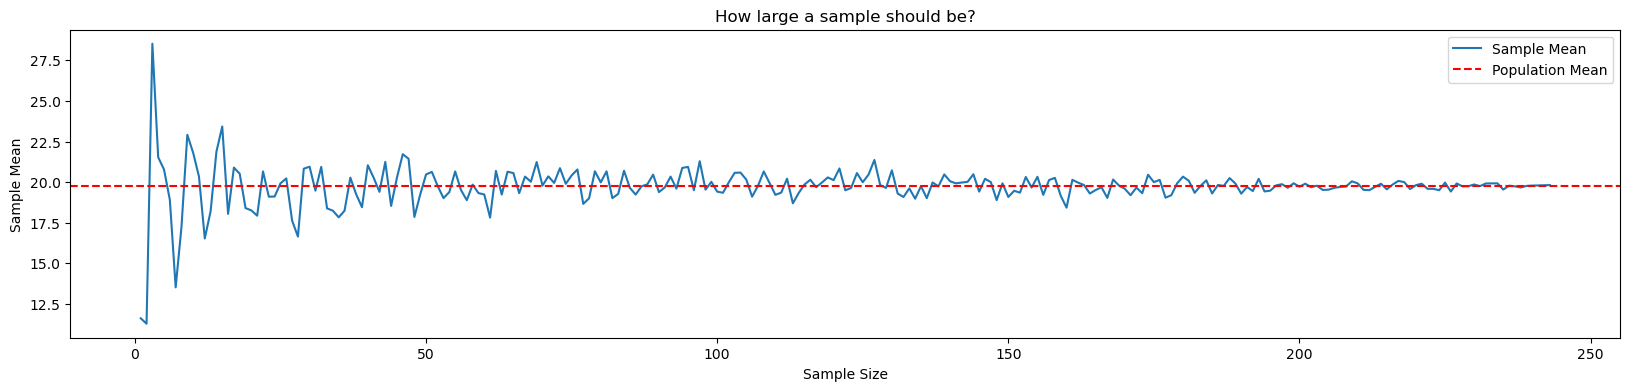

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Tips dataset
tips = sns.load_dataset('tips')

# Treating the tips dataset as the population
population_df = tips.copy()

# Initialize list to store sample sizes and sample means
sample_means = []

# Loop through sample sizes from 1 to 244
for sample_size in np.arange(1, 244):
    # Draw random sample of the given size
    sample_df = population_df.sample(n=sample_size)
    # Append sample size and sample mean
    sample_means.append((sample_size, sample_df['total_bill'].mean()))

# Create DataFrame to store results
sample_means_df = pd.DataFrame(sample_means, columns=['n', 'mean'])

# Display the first few rows of the DataFrame
print(sample_means_df.head())

# Create the plot
fig, ax = plt.subplots(figsize=(20, 4))  # Set figure and axes size

# Add title and axis labels
ax.set_title("How large a sample should be?")
ax.set_xlabel('Sample Size')
ax.set_ylabel('Sample Mean')

# Plot line for sample mean
sns.lineplot(data=sample_means_df, x="n", y="mean", ax=ax, label="Sample Mean")

# Add horizontal line for population mean
ax.axhline(population_df['total_bill'].mean(), ls='--', color='red', label="Population Mean")

# Add legend
ax.legend()

# Show the plot
plt.show()


1. **Population Data**:
   - The `tips` dataset is treated as the population dataset (`population_df`).
   - The variable of interest is `age`.

2. **Sampling Process**:
   - Random samples of varying sizes n = 1 to n = 244 are drawn from the population without replacement.
   - For each sample, the sample mean of the `total_bill` column is calculated.

3. **DataFrame**:
   - The sample size and corresponding sample mean are stored in `sample_means_df`.

4. **Visualization**:
   - A **line plot** displays the relationship between sample size n and sample mean.
   - A **horizontal dashed line** indicates the true population mean for the `age` column, serving as a reference.

**Observations**

1. **Small Sample Sizes ($n \leq 30$)**:
   - Sample means fluctuate significantly due to higher variability.
   - Estimates are unreliable and deviate from the true population mean.

2. **Larger Sample Sizes ($n > 100$)**:
   - Sample means stabilize and converge toward the population mean due to the **Central Limit Theorem** (CLT).
   - Variability decreases significantly, making estimates more precise.

3. **Effectiveness of Large Samples**:
   - Larger samples better represent the population.
   - The sample mean becomes an accurate and reliable point estimate of the population mean.


#### Point Estimation Using m Samples
- Use the **Central Limit Theorem (CLT)** to estimate the population mean by drawing \(m = 1000\) samples of size \(n = 50\).
- **Process**:
  - Calculate sample means for \(m\) samples.
  - Create a **sampling distribution** of these means.
  - Use the mean of the sampling distribution to approximate the population mean.

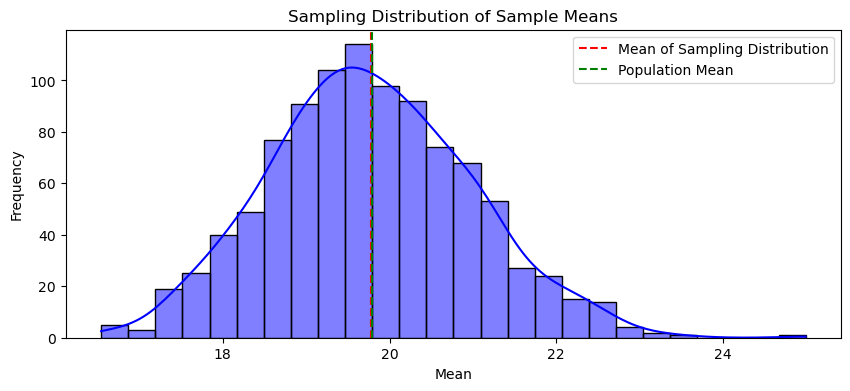

Population mean is estimated to be approximately equal to 19.77.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Tips dataset
tips = sns.load_dataset('tips')

# Treat the tips dataset as the population
population_df = tips.copy()

# Function to compute sampling distribution of sample means
def sampling_distribution(data, sample_size, number_of_samples):
    sample_means = []
    for _ in range(number_of_samples):
        # Take a random sample of size `sample_size` from the population
        sample_df = data.sample(n=sample_size, replace=True)
        # Calculate the sample mean and store it
        sample_means.append(sample_df.mean())
    return pd.DataFrame({'mean': sample_means})

# Parameters
n = 50  # Sample size
m = 1000  # Number of samples

# Create the sampling distribution of sample means
sampling_distribution_df = sampling_distribution(data=population_df['total_bill'], sample_size=n, number_of_samples=m)

# Plot the sampling distribution
def sampling_distribution_plot(data):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.set_title("Sampling Distribution of Sample Means")
    ax.set_xlabel('Mean')
    ax.set_ylabel('Frequency')

    sns.histplot(data, kde=True, ax=ax, color='blue')
    ax.axvline(data.mean(), ls='--', color='red', label="Mean of Sampling Distribution")
    ax.axvline(population_df['total_bill'].mean(), ls='--', color='green', label="Population Mean")

    ax.legend()
    plt.show()

sampling_distribution_plot(data=sampling_distribution_df["mean"])

# Display results
print(f"Population mean is estimated to be approximately equal to {sampling_distribution_df['mean'].mean():.2f}.")

**Challenges**:
  1. **Impracticality**: Collecting many samples is time-consuming and resource-intensive.
  2. **No Reliability Measure**: Point estimates lack information about variability or uncertainty.
  3. **Redundancy**: Often, one large representative sample is sufficient.

Confidence intervals provide a more robust framework for estimating population parameters compared to point estimation, offering insights into both accuracy and reliability.

#### Confidence Interval Estimation  
   Provides a range of values likely to contain the true population mean. For example, a 95% confidence interval means we are 95% confident that the population mean lies within the interval.

**Steps**:
   - **Step 1**: Take a random sample of size n = 50.
   - **Step 2**: Calculate the sample mean ($\bar{x}$) and use the known population standard deviation ($\sigma$).
   - **Step 3**: Compute the margin of error ($MOE = Z \cdot SE$) where $SE = \sigma / \sqrt{n}$.
   - **Step 4**: Use $\bar{x} \pm MOE$ to calculate the confidence interval.

In [4]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns

# Load the Tips dataset
tips = sns.load_dataset('tips')

# Treating the tips dataset as the population
population_df = tips.copy()

# Step 1: Take a random sample from the population
n = 50  # Sample size
sample_df = population_df.sample(n=n, random_state=9)

# Step 2: Calculate the sample statistics
sample_mean = sample_df['total_bill'].mean()  # Sample mean (point estimate)
population_std = population_df['total_bill'].std()  # Population standard deviation (assumed known)

# Step 3: Set confidence level and calculate the margin of error
confidence_level = 0.95
z_critical = stats.norm.ppf(1 - (1 - confidence_level) / 2)  # Z critical value for 95% confidence

# Calculate Standard Error (SE)
SE = population_std / np.sqrt(n)

# Calculate Margin of Error (MOE)
MOE = z_critical * SE

# Step 4: Calculate the confidence interval
lower_bound = sample_mean - MOE
upper_bound = sample_mean + MOE

# Display the results
print(f"Sample Mean (Point Estimate): {sample_mean:.2f}")
print(f"95% Confidence Interval for Population Mean: ({lower_bound:.2f}, {upper_bound:.2f})")

Sample Mean (Point Estimate): 19.25
95% Confidence Interval for Population Mean: (16.78, 21.71)


**Result**: For the "total bill" in the **Tips Dataset**, a 95% confidence interval might be \([16.78, 21.71]\), indicating the true population mean is likely within this range.

**Insights**: Confidence intervals account for sampling variability, offering more reliability than point estimation by providing a range and a confidence level. This method eliminates the impracticality of using multiple samples.

### T distribution vs Normal Distribution

**Key Differences**

1. **Shape**:
   - The **Normal distribution** is bell-shaped and symmetric, with thinner tails.
   - The **T-distribution** is also bell-shaped and symmetric but has **heavier tails**, meaning it allocates more probability in the tails.

2. **Applicability**:
   - **Normal distribution** is used when the population standard deviation ($\sigma$) is known or when the sample size is large ($n > 30$).
   - **T-distribution** is used when \(\sigma\) is unknown and estimated with the sample standard deviation (\(s\)), especially with smaller samples (\(n \leq 30\)).

3. **Heavier Tails**:
   - The heavier tails of the T-distribution account for the additional variability introduced by estimating $\sigma$ using `s` from small samples. This ensures that the critical values are adjusted for smaller sample sizes, providing more conservative confidence intervals or hypothesis tests.

4. **Convergence**:
   - As the **sample size increases ($n \to \infty$)**, the T-distribution approaches the Normal distribution. This happens because the sample standard deviation `s` becomes a more reliable estimate of $\sigma$, reducing uncertainty.


Let’s calculate the critical values for both distributions at a 95% confidence level for two scenarios:
1. A small sample size n = 10, df = n - 1 = 9.
2. A large sample size n = 100, df = n - 1 = 99.



In [5]:
import scipy.stats as stats

# Degrees of freedom
df_small = 9   # Small sample (n = 10, df = 9)
df_large = 99  # Large sample (n = 100, df = 99)

# Critical values for 95% confidence level
z_critical = stats.norm.ppf(1 - 0.05 / 2)  # Z-critical value (Normal distribution)
t_critical_small = stats.t.ppf(1 - 0.05 / 2, df_small)  # T-critical for small sample
t_critical_large = stats.t.ppf(1 - 0.05 / 2, df_large)  # T-critical for large sample

# Display results
print(f"Z-Critical Value (Normal Distribution): {z_critical:.2f}")
print(f"T-Critical Value (T-Distribution, df=9): {t_critical_small:.2f}")
print(f"T-Critical Value (T-Distribution, df=99): {t_critical_large:.2f}")

Z-Critical Value (Normal Distribution): 1.96
T-Critical Value (T-Distribution, df=9): 2.26
T-Critical Value (T-Distribution, df=99): 1.98


**Interpretation**

1. **Z-Critical Value (Normal Distribution)**:
   - For a 95% confidence level, the Z-critical value is fixed: **1.96**.
   
2. **T-Critical Values**:
   - For df = 9 (small sample): T = 2.26. The heavier tails of the T-distribution make the critical value larger, reflecting greater variability.
   - For df = 99 (large sample): T = 1.98. As the sample size increases, the T-critical value becomes closer to the Z-critical value 1.96.

**The heavier tails of the T-distribution:: Accounting for Variability**

- Increase the critical values for small samples.
- Ensure wider confidence intervals, reflecting greater uncertainty in estimates due to the unreliability of `s` as an estimate for $\sigma\$.

#### **Visualizing the Difference**

If you compare the Normal and T-distributions graphically:
1. For small df, the T-distribution has visibly heavier tails, meaning there's a higher probability of observing extreme values.
2. As $df \to \infty$, the T-distribution converges to the Normal distribution, as the sample becomes large enough to reduce variability.

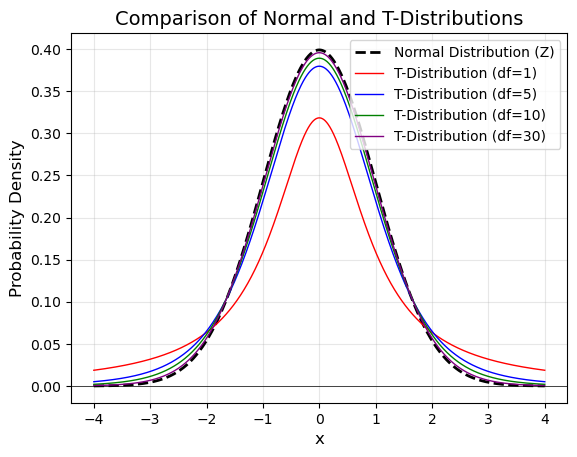

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# Define the x-axis range for the distributions
x = np.linspace(-4, 4, 1000)

# Plot the Normal Distribution
plt.plot(x, norm.pdf(x), label="Normal Distribution (Z)", color="black", linestyle="--", linewidth=2)

# Plot T-Distributions with varying degrees of freedom (df)
dfs = [1, 5, 10, 30]  # Degrees of freedom
colors = ["red", "blue", "green", "purple"]

for df, color in zip(dfs, colors):
    plt.plot(x, t.pdf(x, df), label=f"T-Distribution (df={df})", color=color, linewidth=1)

# Add labels, legend, and title
plt.title("Comparison of Normal and T-Distributions", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.axhline(0, color="black", linewidth=0.5, linestyle="-")
plt.legend()
plt.grid(alpha=0.3)

# Show the plot
plt.show()

### Confidence Interval Estimation with T-Statistic

When the sample size is small (n < 30) and the population standard deviation ($\sigma$) is unknown, the **t-distribution** is used instead of the z-distribution for confidence interval estimation.

**Steps**

1. **Take a Random Sample**:  
   Draw a sample of size (n = 25) from the population.

2. **Calculate Sample Statistics**:  
   Compute the **sample mean ($\bar{x}$)** and the **sample standard deviation s**.

3. **Set Confidence Level and Calculate Margin of Error**:  
   - Calculate the **Standard Error (SE)**:
   $$SE = \frac{s}{\sqrt{n}}$$  
   - Determine the critical value (t-score) using the t-distribution with df = n - 1.  
   - Compute the **Margin of Error (MOE)**:
   $$MOE = t_{\text{critical}} \cdot SE$$.

4. **Estimate the Confidence Interval**:  
   $$
   CI = \bar{x} \pm MOE
   $$

In [7]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns

# Load the Tips dataset
tips = sns.load_dataset('tips')

# Treating the tips dataset as the population
population_df = tips.copy()

# Step 1: Take a random sample from the population
n = 25  # Sample size
sample_df = population_df.sample(n=n, random_state=9)

# Step 2: Calculate the sample statistics
sample_mean = sample_df['total_bill'].mean()  # Sample mean (point estimate)
sample_std = sample_df['total_bill'].std()    # Sample standard deviation

# Step 3: Set confidence level and calculate the margin of error
confidence_level = 0.95  # 95% confidence level
df = n - 1  # Degrees of freedom

# Calculate the critical value (t-score) for 95% confidence level
t_critical = stats.t.ppf(1 - (1 - confidence_level) / 2, df)

# Calculate Standard Error (SE)
SE = sample_std / np.sqrt(n)

# Calculate Margin of Error (MOE)
MOE = t_critical * SE

# Step 4: Calculate the confidence interval
lower_bound = sample_mean - MOE
upper_bound = sample_mean + MOE

# Display the results
print(f"Sample Mean (Point Estimate): {sample_mean:.2f}")
print(f"Sample Standard Deviation: {sample_std:.2f}")
print(f"95% Confidence Interval for Population Mean: ({lower_bound:.2f}, {upper_bound:.2f})")


Sample Mean (Point Estimate): 19.54
Sample Standard Deviation: 11.07
95% Confidence Interval for Population Mean: (14.97, 24.10)


**Results**

For a 95% confidence level:  
- **Point Estimate (Sample Mean)**: e.g., 19.25 units.  
- **Confidence Interval**: e.g., \([14.97, 24.10]\), indicating the population mean likely lies within this range.